<a href="https://colab.research.google.com/github/Krish-sharma-2003/ML-s-Google-Colab-Practice-Notes/blob/main/Stochastic_GD_vs_Vanilla_GD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
def generate_data(num_samples):
  np.random.seed(42)
  X = np.random.rand(num_samples, 1) * 10 #features
  y = 3 * X + 7 + np.random.randn(num_samples, 1) #target with some noise
  return X, y


In [ ]:
def compute_loss(y_true, y_pred):
  return np.mean((y_true - y_pred)**2)

In [ ]:
def batch_Gradient_descent(X, y, epochs, lr=0.01):
  m, n = X.shape
  X = np.c_[np.ones((m, 1)), X]   # Add bias term
  theta = np.random.randn(n + 1, 1)
  losses = []

  for epoch in range(epochs):
    predictions = X.dot(theta)
    errors = predictions - y
    gradients = 2 / m * X.T.dot(errors)
    theta -= lr * gradients
    loss = compute_loss(y, predictions)
    losses.append(loss)

  return theta, losses


In [ ]:
def stochastic_Gradient_descent(X, y, epochs, lr=0.01):
  m, n = X.shape
  X = np.c_[np.ones((m, 1)), X]   # Add bias term
  theta = np.random.randn(n + 1, 1)
  losses = []

  for epoch in range(epochs):
    random_index = np.random.randint(m)
    xi = X[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    predictions = xi.dot(theta)
    errors = predictions - yi  # Changed from 'y' to 'yi'
    gradients = 2 * xi.T.dot(errors)
    theta -= lr * gradients
    loss = compute_loss(yi, predictions)
    losses.append(loss)

  return theta, losses

In [ ]:
small_dataset_size = 1000
large_dataset_size = 100000000

X_small, y_small = generate_data(small_dataset_size)
x_large, y_large = generate_data(large_dataset_size)

In [ ]:
# for small datasets
start_time = time.time()
theta_bgd_small, losses_bgd_small = batch_Gradient_descent(X_small, y_small, epochs=50)
time_bgd_small = time.time() - start_time

# for large datasets
start_time = time.time()
theta_bgd_large, losses_bgd_large = batch_Gradient_descent(x_large, y_large, epochs=50)
time_bgd_large = time.time() - start_time

In [ ]:
# for small datasets
start_time = time.time()
theta_sgd_small, losses_sgd_small = stochastic_Gradient_descent(X_small, y_small, epochs=50)
time_sgd_small = time.time() - start_time

# for large datasets
start_time = time.time()
theta_sgd_large, losses_sgd_large = stochastic_Gradient_descent(x_large, y_large, epochs=50)
time_sgd_large = time.time() - start_time

In [ ]:
print("Batch Gradient Descent (Small Datasets): Time = {:.4f}s, Final Loss = {:.4f}".format(time_bgd_small, losses_bgd_small[-1]))
print("Batch Gradient Descent (Large Datasets): Time = {:.4f}s, Final Loss = {:.4f}".format(time_bgd_large, losses_bgd_large[-1]))
print("Stochastic Gradient Descent (Small Datasets): Time = {:.4f}s, Final Loss = {:.4f}".format(time_sgd_small, losses_sgd_small[-1]))
print("Stochastic Gradient Descent (Large Datasets): Time = {:.4f}s, Final Loss = {:.4f}".format(time_sgd_large, losses_sgd_large[-1]))

Batch Gradient Descent (Small Datasets): Time = 0.0038s, Final Loss = 6.4281
Batch Gradient Descent (Large Datasets): Time = 89.7982s, Final Loss = 12.3086
Stochastic Gradient Descent (Small Datasets): Time = 0.0032s, Final Loss = 10.5045
Stochastic Gradient Descent (Large Datasets): Time = 0.9833s, Final Loss = 0.0266


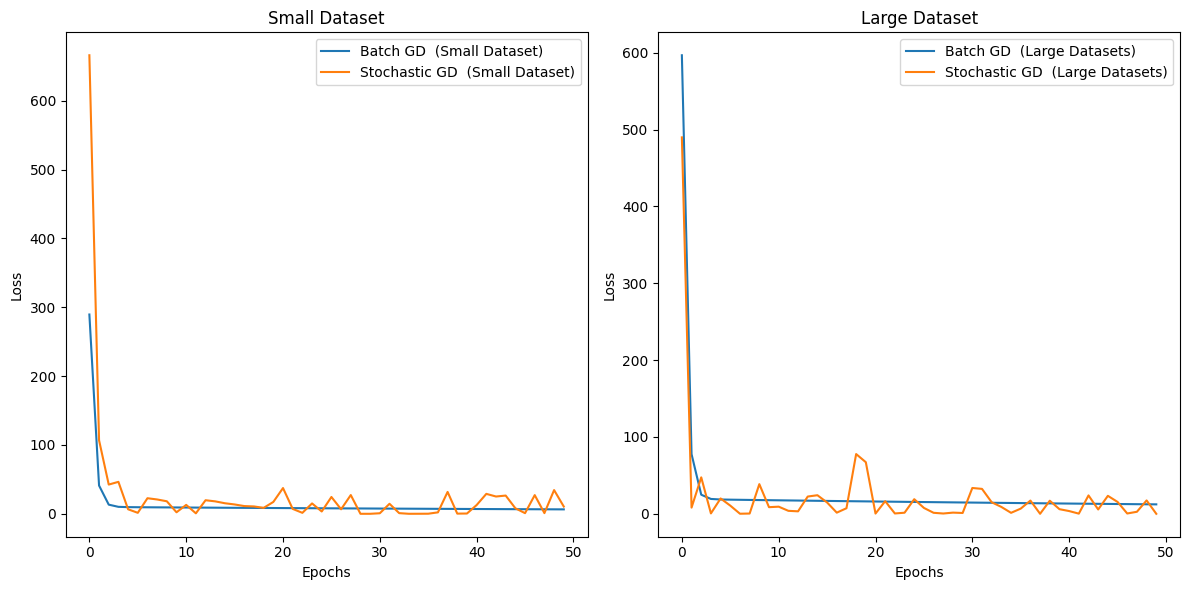

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(losses_bgd_small, label="Batch GD  (Small Dataset)")
plt.plot(losses_sgd_small, label="Stochastic GD  (Small Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Small Dataset")

plt.subplot(1, 2, 2)
plt.plot(losses_bgd_large, label="Batch GD  (Large Datasets)")
plt.plot(losses_sgd_large, label="Stochastic GD  (Large Datasets)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Large Dataset")

plt.tight_layout()
plt.show()